# Dynamic Model in Levels


In [1]:
import os
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

import doubleml as dml

from utils.utils_data2 import (
    get_cis,
    generate_basis,
    generate_interactions,
)

from utils.utils_models import (
    iv_model,
    lin_model,
    lin_model_cate,
    summarize_lin_model,
    summarize_dml,
    chi2_test,
    predict_cate,
)

# Get a colorblind-friendly palette
palette = sns.color_palette("colorblind")

confidence_level = 0.9
ci_level_name, ci_names = get_cis(confidence_level)

output_dir = "../../output/A4_replication_clothes_data/02_output_evaluation"
Path(output_dir).mkdir(parents=True, exist_ok=True)

Confidence Level: 90.0%


In [2]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"
df_full_train = pd.read_csv(f"../../data/A4_replication_clothes_data/{dataframe_name}_train.zip")
df_full_val = pd.read_csv(f"../../data/A4_replication_clothes_data/{dataframe_name}_val.zip")

columns_to_drop = [
    "Q_t-2",
    "P_bb_t-2",
    "REVIEW_COUNT_t-2",
    "RATING_t-2",
    "pred_ml_l_lag_1",
    "pred_ml_m_lag_1",
]

df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [
    category for category in df_full_val["subcat_aggregated"].unique()
]
all_time_steps = sorted([str(date) for date in df_full_val["date"].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

Dummy subcat names: ['Residual', 'T-Shirts', 'Casual', 'Active Shorts', 'Sunglasses', 'Tunics', 'Fashion Sneakers', 'Everyday Bras', 'Cardigans', 'Sports Bras', 'Tanks & Camis', 'Pullovers', 'Briefs', 'Button-Down Shirts', 'Cover-Ups', 'Women, Skirts', 'Slippers', 'Leggings', 'Sets', 'Jeans', 'Blouses & Button-Down Shirts']
All time steps: ['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29', '2024-02-26', '2024-03-25']


Index(['ASIN', 'date', 'index', 'Q_t', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'Anzahl Neu Angebote: Aktuell',
       ...
       'emb_254', 'emb_255', 'Q_t-1', 'P_bb_t-1', 'REVIEW_COUNT_t-1',
       'RATING_t-1', 'Delta_Q_t', 'Delta_P_bb_t', 'pred_ml_l', 'pred_ml_m'],
      dtype='object', length=347)

In [3]:
df_full_val.isna().sum()

ASIN            0
date            0
index           0
Q_t             0
P_bb_t          0
               ..
RATING_t-1      0
Delta_Q_t       0
Delta_P_bb_t    0
pred_ml_l       0
pred_ml_m       0
Length: 347, dtype: int64

In [4]:
df_full_train["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29', '2024-02-26', '2024-03-25'], dtype=object)

In [5]:
df_full_val["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29', '2024-02-26', '2024-03-25'], dtype=object)

In [6]:
df_full_train["ASIN"].nunique()

1191

In [7]:
df_full_val["ASIN"].nunique()

1210

In [8]:
from datetime import datetime

date_objects = [datetime.strptime(date, "%Y-%m-%d") for date in all_time_steps]

# Calculate the difference in days between consecutive dates
date_differences = [
    (date_objects[i + 1] - date_objects[i]).days for i in range(len(date_objects) - 1)
]

# Print the differences
print(date_differences)

[28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


## Variable Names

In [9]:
n_lags = 1

outcome = ["Q_t"]
base_treatment = ["P_bb_t"]
lag_1_vars = ["Q_t-1", "P_bb_t-1"]

dummy_time_steps = all_time_steps[n_lags:]

all_dummy_controls = dummy_subcat_names + dummy_time_steps
dummy_baselines = [dummy_time_steps[0], "Residual"]
dummy_time_steps_wo_baseline = [t for t in dummy_time_steps if t not in dummy_baselines]
dummy_controls = [t for t in all_dummy_controls if t not in dummy_baselines]

cont_controls = [
    "RATING_t-1",
    "REVIEW_COUNT_t-1",
    "Anzahl Neu Angebote: Aktuell",
    "Anzahl der abgerufenen Live-Angebote: Neu, FBA",
    "Anzahl der abgerufenen Live-Angebote: Neu, FBM",
    #    "weighted_substitute_price",
]

add_controls_to_scale = [
    "RATING",
    "REVIEW_COUNT",
]

controls_pca = ["pca_0", "pca_1", "pca_2", "pca_3", "pca_4"]

controls_similarities = [
    "similarity_cluster_0",
    "similarity_cluster_1",
    "similarity_cluster_2",
    "similarity_cluster_3",
    "similarity_cluster_4",
]

embeddings = [f"emb_{i}" for i in range(256)]

controls_to_scale = cont_controls + add_controls_to_scale

additional_controls = cont_controls + dummy_controls

## Interactions & CATE Basis

In [10]:
basis_vars = controls_similarities + lag_1_vars
df_basis, column_transformer, column_dict = generate_basis(
    df=df_full_val,
    cols_without_scaling=controls_similarities,
    cols_to_scale=lag_1_vars,
    degree=1,
)
df_basis.head()

,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,1.108824,-2.561720,-0.090924,0.795701,0.477067,-0.830146,-0.735317
1,1.0,-0.039231,-2.159645,0.338004,0.692736,0.195288,-0.532244,-0.702744
2,1.0,0.718854,-0.089486,-0.388050,-0.888852,-0.284905,0.689886,0.877391
3,1.0,0.649017,0.253484,0.183060,-0.423084,-0.376687,0.509787,0.321425
4,1.0,1.330221,-2.561720,-0.461370,0.624563,0.826551,-0.823152,-0.350434


In [11]:
df_interact_val, interaction_vars = generate_interactions(
    df=df_full_val, df_basis=df_basis, cols_to_interact=["Q_t-1", "P_bb_t-1"]
)

print(f"Interactions: {interaction_vars}")
df_interact_val.columns

Interactions: ['interaction_Q_t-1_intercept', 'interaction_Q_t-1_Q_t-1', 'interaction_Q_t-1_P_bb_t-1', 'interaction_Q_t-1_similarity_cluster_0', 'interaction_Q_t-1_similarity_cluster_1', 'interaction_Q_t-1_similarity_cluster_2', 'interaction_Q_t-1_similarity_cluster_3', 'interaction_Q_t-1_similarity_cluster_4', 'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1', 'interaction_P_bb_t-1_P_bb_t-1', 'interaction_P_bb_t-1_similarity_cluster_0', 'interaction_P_bb_t-1_similarity_cluster_1', 'interaction_P_bb_t-1_similarity_cluster_2', 'interaction_P_bb_t-1_similarity_cluster_3', 'interaction_P_bb_t-1_similarity_cluster_4']


Index(['ASIN', 'date', 'index', 'Q_t', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'Anzahl Neu Angebote: Aktuell',
       ...
       'interaction_Q_t-1_similarity_cluster_3',
       'interaction_Q_t-1_similarity_cluster_4',
       'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1',
       'interaction_P_bb_t-1_P_bb_t-1',
       'interaction_P_bb_t-1_similarity_cluster_0',
       'interaction_P_bb_t-1_similarity_cluster_1',
       'interaction_P_bb_t-1_similarity_cluster_2',
       'interaction_P_bb_t-1_similarity_cluster_3',
       'interaction_P_bb_t-1_similarity_cluster_4'],
      dtype='object', length=363)

## Average Effect

In [12]:
df_dynamic = df_interact_val.copy()

### Linear Models

In [13]:
def estimate_linear_model(controls):
    model = lin_model(
        df=df_dynamic,
        outcome=outcome,
        treatments=base_treatment,
        controls=controls,
        level=confidence_level,
        cov_type="cluster",
        cov_kwds={"groups": df_dynamic["ASIN"]},
    )
    return model

In [14]:
estimate_linear_model(controls=[])

Adjusted R^2: 0.015
         coef  std err       t  P>|t|  [5.0%  95.0%]
const  -7.752    0.270 -28.715    0.0 -8.196  -7.308
P_bb_t -0.391    0.083  -4.691    0.0 -0.529  -0.254


,lower,upper,coef
P_bb_t,-0.528595,-0.254126,-0.391361


In [15]:
ci_linear_base_lagged = estimate_linear_model(controls=lag_1_vars)

Adjusted R^2: 0.8177
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -0.812    0.061  -13.321    0.0 -0.912  -0.712
P_bb_t   -0.625    0.117   -5.340    0.0 -0.817  -0.432
Q_t-1     0.889    0.006  147.141    0.0  0.879   0.899
P_bb_t-1  0.574    0.117    4.922    0.0  0.382   0.766


In [16]:
ci_linear_embeddings = estimate_linear_model(controls=lag_1_vars + embeddings)

Adjusted R^2: 0.8233
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -1.243    0.097  -12.849  0.000 -1.402  -1.084
P_bb_t   -0.609    0.113   -5.412  0.000 -0.794  -0.424
Q_t-1     0.835    0.007  116.488  0.000  0.823   0.847
P_bb_t-1  0.542    0.114    4.768  0.000  0.355   0.729
emb_0     0.424    0.416    1.018  0.309 -0.261   1.108
...         ...      ...      ...    ...    ...     ...
emb_251  -0.563    0.408   -1.381  0.167 -1.234   0.108
emb_252   1.593    0.456    3.492  0.000  0.843   2.344
emb_253  -0.123    0.441   -0.279  0.781 -0.848   0.602
emb_254   0.720    0.514    1.402  0.161 -0.125   1.565
emb_255   0.155    0.446    0.347  0.728 -0.578   0.888

[260 rows x 6 columns]


In [17]:
ci_linear_base_lagged_add_controls = estimate_linear_model(
    controls=lag_1_vars + additional_controls
)

Adjusted R^2: 0.8234
                                                 coef  std err        t  \
const                                          -1.198    0.162   -7.402   
P_bb_t                                         -0.566    0.115   -4.920   
Q_t-1                                           0.875    0.007  132.169   
P_bb_t-1                                        0.521    0.115    4.521   
RATING_t-1                                      0.051    0.033    1.559   
REVIEW_COUNT_t-1                                0.000    0.000    3.561   
Anzahl Neu Angebote: Aktuell                   -0.007    0.013   -0.510   
Anzahl der abgerufenen Live-Angebote: Neu, FBA  0.023    0.016    1.382   
Anzahl der abgerufenen Live-Angebote: Neu, FBM -0.004    0.020   -0.212   
T-Shirts                                        0.128    0.041    3.092   
Casual                                          0.055    0.031    1.787   
Active Shorts                                   0.149    0.062    2.392   
Sung

In [18]:
ci_linear_base_lagged_add_controls_emb = estimate_linear_model(
    controls=lag_1_vars + additional_controls + embeddings
)

Adjusted R^2: 0.8286
             coef  std err        t  P>|t|  [5.0%  95.0%]
const      -1.849    0.197   -9.370  0.000 -2.174  -1.525
P_bb_t     -0.555    0.111   -4.982  0.000 -0.739  -0.372
Q_t-1       0.823    0.008  104.312  0.000  0.810   0.836
P_bb_t-1    0.488    0.113    4.334  0.000  0.303   0.673
RATING_t-1  0.123    0.037    3.324  0.001  0.062   0.184
...           ...      ...      ...    ...    ...     ...
emb_251    -0.294    0.441   -0.667  0.505 -1.019   0.431
emb_252     1.650    0.517    3.190  0.001  0.800   2.501
emb_253    -0.232    0.462   -0.503  0.615 -0.992   0.527
emb_254     0.492    0.551    0.893  0.372 -0.414   1.398
emb_255     0.321    0.480    0.670  0.503 -0.468   1.110

[298 rows x 6 columns]


In [19]:
ci_linear_base_lagged_add_controls_sim = estimate_linear_model(
    controls=lag_1_vars + controls_similarities + additional_controls
)

Adjusted R^2: 0.827
                                                 coef  std err        t  \
const                                          -1.753    0.177   -9.888   
P_bb_t                                         -0.561    0.112   -5.014   
Q_t-1                                           0.852    0.007  115.296   
P_bb_t-1                                        0.529    0.113    4.681   
similarity_cluster_0                           -1.134    0.335   -3.386   
similarity_cluster_1                            2.695    0.730    3.691   
similarity_cluster_2                            0.052    0.423    0.122   
similarity_cluster_3                            2.961    0.808    3.663   
similarity_cluster_4                           -0.246    0.626   -0.393   
RATING_t-1                                      0.121    0.034    3.594   
REVIEW_COUNT_t-1                                0.000    0.000    3.751   
Anzahl Neu Angebote: Aktuell                   -0.014    0.015   -0.943   
Anzah

In [20]:
ci_linear_interactions = estimate_linear_model(
    controls=interaction_vars + controls_similarities + additional_controls
)

Adjusted R^2: 0.8277
                              coef  std err      t  P>|t|  [5.0%  95.0%]
const                       -0.642    0.721 -0.890  0.373 -1.827   0.544
P_bb_t                      -0.563    0.110 -5.102  0.000 -0.744  -0.381
interaction_Q_t-1_intercept  0.714    0.075  9.557  0.000  0.591   0.836
interaction_Q_t-1_Q_t-1     -0.000    0.007 -0.011  0.991 -0.011   0.011
interaction_Q_t-1_P_bb_t-1  -0.049    0.008 -6.233  0.000 -0.062  -0.036
...                            ...      ...    ...    ...    ...     ...
2023-12-04                  -0.008    0.034 -0.235  0.814 -0.063   0.047
2024-01-01                  -0.226    0.029 -7.914  0.000 -0.273  -0.179
2024-01-29                   0.191    0.026  7.218  0.000  0.147   0.234
2024-02-26                   0.034    0.025  1.387  0.165 -0.006   0.074
2024-03-25                  -0.054    0.023 -2.418  0.016 -0.091  -0.017

[61 rows x 6 columns]


In [21]:
ci_linear_base_lagged["model"] = "Linear lagged"
ci_linear_embeddings["model"] = "Linear lagged_and_embeddings"
ci_linear_base_lagged_add_controls["model"] = "Linear lagged_and_add_controls"
ci_linear_base_lagged_add_controls_emb["model"] = (
    "Linear lagged_and_add_controls_and_emb"
)
ci_linear_base_lagged_add_controls_sim["model"] = (
    "Linear lagged_and_add_controls_and_ReLU_features"
)
ci_linear_interactions["model"] = "Linear interactions"

df_base = pd.concat(
    [
        ci_linear_base_lagged,
        ci_linear_embeddings,
        ci_linear_base_lagged_add_controls,
        ci_linear_base_lagged_add_controls_emb,
        ci_linear_base_lagged_add_controls_sim,
    ],
    ignore_index=True,
)

In [22]:
df_base

,lower,upper,coef,model
0,-0.817278,-0.432337,-0.624807,Linear lagged
1,-0.794478,-0.424109,-0.609293,Linear lagged_and_embeddings
2,-0.755678,-0.376993,-0.566335,Linear lagged_and_add_controls
3,-0.738510,-0.371894,-0.555202,Linear lagged_and_add_controls_and_emb
4,-0.744514,-0.376721,-0.560617,Linear lagged_and_add_controls_and_ReLU_features


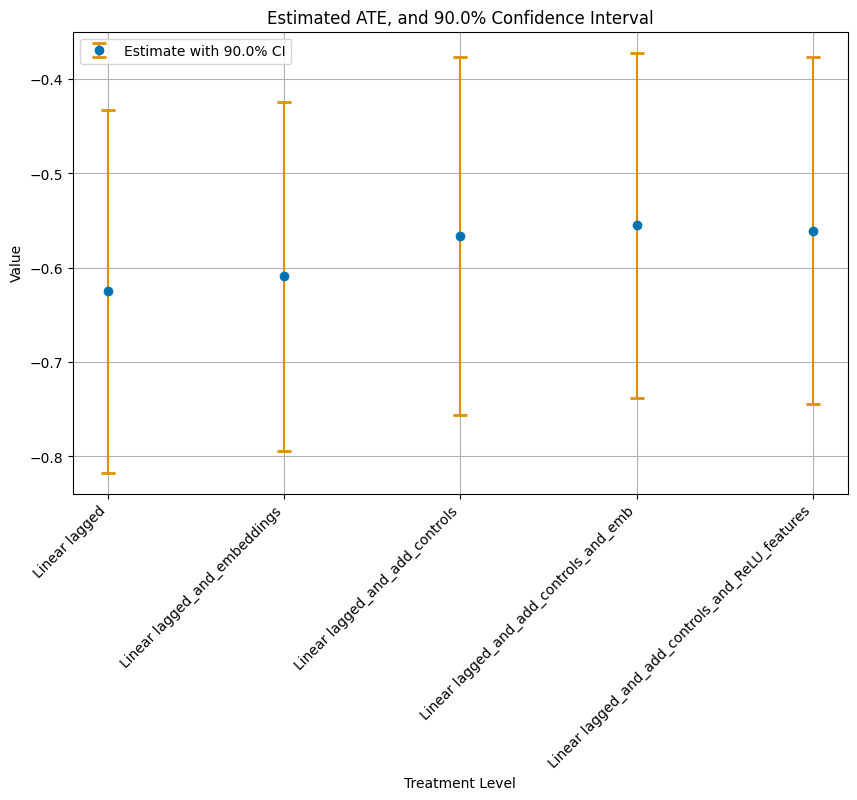

In [23]:
# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(
    df_base["model"],
    df_base["coef"],
    yerr=[df_base["coef"] - df_base["lower"], df_base["upper"] - df_base["coef"]],
    fmt="o",
    capsize=5,
    capthick=2,
    ecolor=palette[1],
    color=palette[0],
    label=f"Estimate with {round(confidence_level * 100, 1)}% CI",
    zorder=2,
)

plt.title(f"Estimated ATE, and {round(confidence_level * 100, 1)}% Confidence Interval")
plt.xlabel("Treatment Level")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"linear_ate_estimates.png"))
plt.show()

In [24]:
df_base

,lower,upper,coef,model
0,-0.817278,-0.432337,-0.624807,Linear lagged
1,-0.794478,-0.424109,-0.609293,Linear lagged_and_embeddings
2,-0.755678,-0.376993,-0.566335,Linear lagged_and_add_controls
3,-0.738510,-0.371894,-0.555202,Linear lagged_and_add_controls_and_emb
4,-0.744514,-0.376721,-0.560617,Linear lagged_and_add_controls_and_ReLU_features


### DML Models

In [25]:
ml_g = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)
ml_m = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)


def r2(y_true, y_pred):
    subset = np.logical_not(np.isnan(y_true))
    return r2_score(y_true[subset], y_pred[subset])


def estimate_dml_model(controls):
    tab_dml_data = dml.DoubleMLClusterData(
        df_dynamic,
        y_col=outcome[0],
        d_cols=base_treatment,
        x_cols=controls,
        cluster_cols="ASIN",
    )

    np.random.seed(3141)
    tab_dml_obj = dml.DoubleMLPLR(tab_dml_data, ml_g, ml_m)
    tab_dml_obj.fit()

    tab_summary_df = summarize_dml(tab_dml_obj, level=confidence_level)
    ci_tab_dml = tab_summary_df[ci_names + ["coef"]]
    ci_tab_dml.columns = ["lower", "upper", "coef"]

    r2_scores = tab_dml_obj.evaluate_learners(metric=r2)
    print(
        f"R2 Outcome: {round(r2_scores['ml_l'][0, 0], 4)} R2 Treatment: {round(r2_scores['ml_m'][0, 0], 4)}\n"
    )

    return tab_dml_obj, ci_tab_dml

In [26]:
tab_dml_obj_embeddings, ci_tab_dml_embeddings = estimate_dml_model(
    controls=lag_1_vars + embeddings
)

C:\Users\Work\AppData\Local\Temp\ipykernel_32656\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

         coef  std err      t  P>|t|   5.0%  95.0%
P_bb_t -0.626    0.153 -4.106    0.0 -0.877 -0.375
R2 Outcome: 0.7608 R2 Treatment: 0.9771



In [27]:
tab_dml_obj_add_controls, ci_tab_dml_add_controls = estimate_dml_model(
    controls=lag_1_vars + additional_controls
)

C:\Users\Work\AppData\Local\Temp\ipykernel_32656\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

         coef  std err      t  P>|t|   5.0%  95.0%
P_bb_t -0.516    0.135 -3.828    0.0 -0.738 -0.294
R2 Outcome: 0.8067 R2 Treatment: 0.98



In [28]:
tab_dml_obj_embeddings_add_controls, ci_tab_dml_embeddings_add_controls = (
    estimate_dml_model(controls=lag_1_vars + embeddings + additional_controls)
)

C:\Users\Work\AppData\Local\Temp\ipykernel_32656\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

         coef  std err      t  P>|t|   5.0%  95.0%
P_bb_t -0.658    0.125 -5.243    0.0 -0.864 -0.451
R2 Outcome: 0.8128 R2 Treatment: 0.978



In [29]:
tab_dml_obj_sim_add_controls, ci_tab_dml_sim_add_controls = estimate_dml_model(
    controls=lag_1_vars + controls_similarities + additional_controls
)

C:\Users\Work\AppData\Local\Temp\ipykernel_32656\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

        coef  std err      t  P>|t|   5.0%  95.0%
P_bb_t -0.65    0.125 -5.196    0.0 -0.855 -0.444
R2 Outcome: 0.8154 R2 Treatment: 0.9797



In [30]:
tab_dml_obj_pca_add_controls, ci_tab_dml_pca_add_controls = estimate_dml_model(
    controls=lag_1_vars + controls_pca + additional_controls
)

C:\Users\Work\AppData\Local\Temp\ipykernel_32656\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

         coef  std err      t  P>|t|   5.0%  95.0%
P_bb_t -0.699    0.114 -6.107    0.0 -0.887 -0.511
R2 Outcome: 0.8161 R2 Treatment: 0.9797



### Visualization

In [31]:
ci_tab_dml_embeddings["model"] = "plr_embeddings"
ci_tab_dml_add_controls["model"] = "plr_add_controls"
ci_tab_dml_embeddings_add_controls["model"] = "plr_embeddings_add_controls"
ci_tab_dml_sim_add_controls["model"] = "plr_ReLU_feat_add_controls"
ci_tab_dml_pca_add_controls["model"] = "plr_pca_add_controls"


df_averages = pd.concat(
    [
        ci_tab_dml_embeddings,
        ci_tab_dml_add_controls,
        ci_tab_dml_embeddings_add_controls,
        ci_tab_dml_sim_add_controls,
        ci_tab_dml_pca_add_controls,
    ],
    ignore_index=True,
)

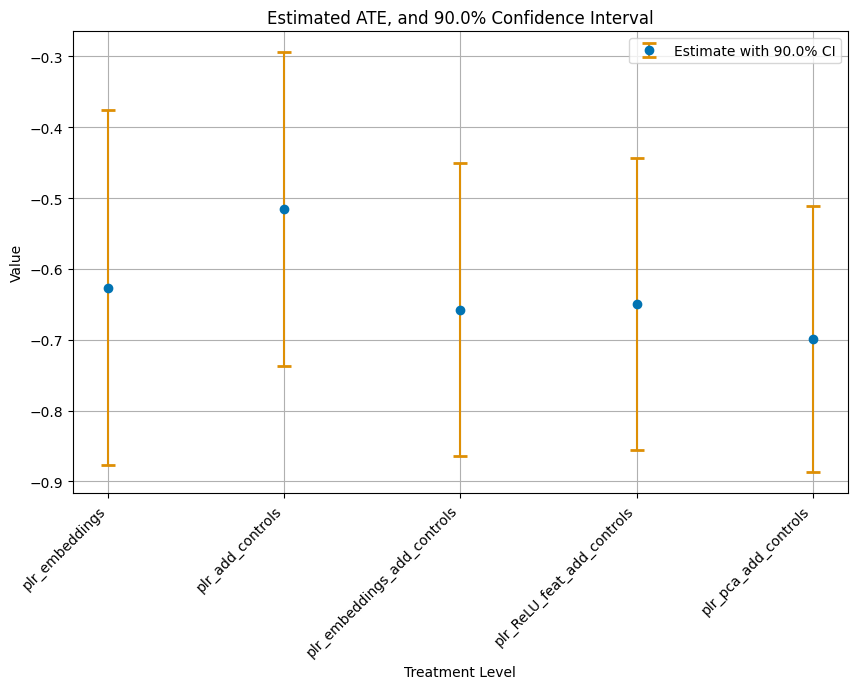

In [32]:
# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(
    df_averages["model"],
    df_averages["coef"],
    yerr=[
        df_averages["coef"] - df_averages["lower"],
        df_averages["upper"] - df_averages["coef"],
    ],
    fmt="o",
    capsize=5,
    capthick=2,
    ecolor=palette[1],
    color=palette[0],
    label=f"Estimate with {round(confidence_level * 100, 1)}% CI",
    zorder=2,
)

plt.title(f"Estimated ATE, and {round(confidence_level * 100, 1)}% Confidence Interval")
plt.xlabel("Treatment Level")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"plr_ate_estimates.png"))
plt.show()

## GATEs

In [33]:
df_dynamic[controls_similarities]

,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,-0.058463,0.797075,0.488575,-0.813937,-0.721108
1,0.370465,0.694109,0.206797,-0.516035,-0.688535
2,-0.355589,-0.887479,-0.273397,0.706095,0.891599
3,0.215521,-0.421710,-0.365179,0.525996,0.335634
4,-0.428909,0.625936,0.838060,-0.806943,-0.336225
...,...,...,...,...,...
13729,-0.116334,-0.903007,-0.477427,0.834454,0.816924
13730,-0.162405,0.819084,0.691386,-0.870477,-0.614849
13731,-0.023085,-0.887607,-0.555057,0.877325,0.773168
13732,0.322216,-0.243748,-0.316709,0.402057,0.174646


In [34]:
controls_similarities

['similarity_cluster_0',
 'similarity_cluster_1',
 'similarity_cluster_2',
 'similarity_cluster_3',
 'similarity_cluster_4']

0
similarity_cluster_0    1791
similarity_cluster_1    3915
similarity_cluster_2    2297
similarity_cluster_3    3157
similarity_cluster_4    2574
dtype: int64


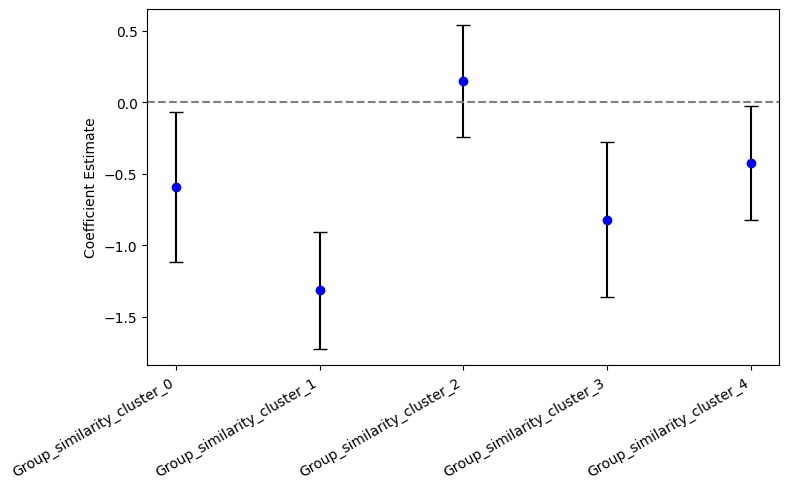

In [35]:
groups = pd.DataFrame(df_dynamic[controls_similarities].idxmax(axis=1))

print(groups.groupby(0).size())
gates_0 = tab_dml_obj_embeddings.gate(groups)
gates_0_summ = gates_0.summary
gates_0_summ["err_lower"] = gates_0_summ["coef"] - gates_0_summ["[0.025"]
gates_0_summ["err_upper"] = gates_0_summ["0.975]"] - gates_0_summ["coef"]

# Positions on the x-axis
x_vals = range(len(gates_0_summ))

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=x_vals,
    y=gates_0_summ["coef"],
    yerr=[gates_0_summ["err_lower"], gates_0_summ["err_upper"]],
    fmt="o",
    capsize=5,
    color="blue",
    ecolor="black",
)

# Draw a zero line for reference
plt.axhline(y=0, color="gray", linestyle="--")

# Customizing x-axis labels
plt.xticks(
    ticks=x_vals,
    labels=[gr.replace("outcome_feature", "") for gr in gates_0_summ.index],
    rotation=30,
    ha="right",
)
plt.ylabel("Coefficient Estimate")
plt.tight_layout()
plt.show()

## CATEs

In [36]:
uniform_ci = True  # False | True

In [37]:
cate_controls = lag_1_vars + embeddings + additional_controls
cate_controls_interactions = cate_controls + interaction_vars

plr_obj = tab_dml_obj_embeddings_add_controls

In [38]:
# clear RAM to avoid OOM issues
import gc

gc.collect()

9698

In [39]:
df_basis

,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,1.108824,-2.561720,-0.090924,0.795701,0.477067,-0.830146,-0.735317
1,1.0,-0.039231,-2.159645,0.338004,0.692736,0.195288,-0.532244,-0.702744
2,1.0,0.718854,-0.089486,-0.388050,-0.888852,-0.284905,0.689886,0.877391
3,1.0,0.649017,0.253484,0.183060,-0.423084,-0.376687,0.509787,0.321425
4,1.0,1.330221,-2.561720,-0.461370,0.624563,0.826551,-0.823152,-0.350434
...,...,...,...,...,...,...,...,...
13729,1.0,-0.388799,0.924171,-0.148795,-0.904381,-0.488935,0.818245,0.802715
13730,1.0,-1.673683,-1.605176,-0.194865,0.817711,0.679877,-0.886686,-0.629058
13731,1.0,-0.298488,0.842905,-0.055546,-0.888981,-0.566566,0.861116,0.758960
13732,1.0,0.187685,0.684729,0.289756,-0.245121,-0.328218,0.385848,0.160437


In [40]:
cate_kwargs_val = {"cov_type": "cluster", "cov_kwds": {"groups": df_dynamic["ASIN"]}}

cate_models_polynomial = {
    "Linear Specification": None,
    "Linear Specification (Interactions)": None,
    "PLR Specification": None,
}

# Linear Models
cate_models_polynomial["Linear Specification"] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls,
    **cate_kwargs_val,
)

print(f"\nLinear Specification")
df_specification_1 = summarize_lin_model(
    cate_models_polynomial["Linear Specification"], level=confidence_level
)
print("=" * 80)  #

cate_models_polynomial["Linear Specification (Interactions)"] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls_interactions,
    **cate_kwargs_val,
)

print(f"\nLinear specification with interactions")
df_specification_2 = summarize_lin_model(
    cate_models_polynomial["Linear Specification (Interactions)"],
    level=confidence_level,
)
print("=" * 80)

# tabular DML model
cate_models_polynomial["PLR Specification"] = plr_obj.cate(df_basis, **cate_kwargs_val)

print(f"\nTabular DML PLR Specification")
df_specification_3 = summarize_lin_model(
    cate_models_polynomial["PLR Specification"].blp_model, level=confidence_level
)
print("=" * 80)


Linear Specification
                        coef  std err      t  P>|t|    5.0%   95.0%
intercept             -0.620    0.123 -5.021  0.000  -0.823  -0.417
Q_t-1                  0.190    0.146  1.300  0.194  -0.050   0.430
P_bb_t-1              -0.114    0.130 -0.876  0.381  -0.328   0.100
similarity_cluster_0  -7.850    5.188 -1.513  0.130 -16.384   0.684
similarity_cluster_1  -9.240   13.599 -0.679  0.497 -31.608  13.129
similarity_cluster_2  14.447    7.104  2.033  0.042   2.761  26.132
similarity_cluster_3  22.129   12.395  1.785  0.074   1.741  42.517
similarity_cluster_4 -24.922   10.830 -2.301  0.021 -42.736  -7.107

Linear specification with interactions
                        coef  std err      t  P>|t|    5.0%   95.0%
intercept             -0.625    0.121 -5.159  0.000  -0.824  -0.426
Q_t-1                  0.172    0.144  1.192  0.233  -0.065   0.410
P_bb_t-1              -0.123    0.125 -0.989  0.323  -0.328   0.082
similarity_cluster_0  -8.535    5.080 -1.680  0.093 -1

In [41]:
cate_models_polynomial["Linear Specification (Interactions)"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.005
Model:                            OLS   Adj. R-squared (uncentered):              0.004
Method:                 Least Squares   F-statistic:                              5.145
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                    2.51e-06
Time:                        17:32:11   Log-Likelihood:                         -14513.
No. Observations:               13734   AIC:                                  2.904e+04
Df Residuals:                   13726   BIC:                                  2.910e+04
Df Model:                           8                                                  
Covariance Type:              cluster                                                  
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.6249      0.121     -5.159      0.000      -0.862      -0.387
Q_t-1                    0.1721      0.144      1.192      0.233      -0.111       0.455
P_bb_t-1                -0.1232      0.125     -0.989      0.323      -0.367       0.121
similarity_cluster_0    -8.5347      5.080     -1.680      0.093     -18.491       1.421
similarity_cluster_1    -8.4737     13.438     -0.631      0.528     -34.812      17.865
similarity_cluster_2    14.9367      7.103      2.103      0.035       1.015      28.858
similarity_cluster_3    23.9003     12.236      1.953      0.051      -0.082      47.883
similarity_cluster_4   -25.7111     10.816     -2.377      0.017     -46.911      -4.511
==============================================================================
Omnibus:                     3374.544   Durbin-Watson:                   1.891
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           198606.149
Skew:                          -0.235   Prob(JB):                         0.00
Kurtosis:                      21.624   Cond. No.                         259.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

In [42]:
cate_models_polynomial["PLR Specification"].blp_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):              0.007
Method:                 Least Squares   F-statistic:                              4.419
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                    2.75e-05
Time:                        17:32:11   Log-Likelihood:                         -15267.
No. Observations:               13734   AIC:                                  3.055e+04
Df Residuals:                   13726   BIC:                                  3.061e+04
Df Model:                           8                                                  
Covariance Type:              cluster                                                  
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.6808      0.141     -4.832      0.000      -0.957      -0.405
Q_t-1                    0.1309      0.214      0.612      0.541      -0.288       0.550
P_bb_t-1                -0.0970      0.148     -0.654      0.513      -0.388       0.194
similarity_cluster_0    -5.9832      6.046     -0.990      0.322     -17.834       5.867
similarity_cluster_1   -11.8061     15.673     -0.753      0.451     -42.525      18.912
similarity_cluster_2    20.2103      7.474      2.704      0.007       5.561      34.859
similarity_cluster_3    26.0456     14.188      1.836      0.066      -1.763      53.854
similarity_cluster_4   -28.0472     11.249     -2.493      0.013     -50.095      -5.999
==============================================================================
Omnibus:                     3172.860   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            81739.715
Skew:                          -0.515   Prob(JB):                         0.00
Kurtosis:                      14.907   Cond. No.                         299.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

In [43]:
latex_args = {
    "index": True,
    "float_format": "%.3f",
    "column_format": "lcccccc",
}

print(df_specification_1.to_latex(**latex_args))
print(df_specification_2.to_latex(**latex_args))
print(df_specification_3.to_latex(**latex_args))

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.620 & 0.123 & -5.021 & 0.000 & -0.823 & -0.417 \\
Q_t-1 & 0.190 & 0.146 & 1.300 & 0.194 & -0.050 & 0.430 \\
P_bb_t-1 & -0.114 & 0.130 & -0.876 & 0.381 & -0.328 & 0.100 \\
similarity_cluster_0 & -7.850 & 5.188 & -1.513 & 0.130 & -16.384 & 0.684 \\
similarity_cluster_1 & -9.240 & 13.599 & -0.679 & 0.497 & -31.608 & 13.129 \\
similarity_cluster_2 & 14.447 & 7.104 & 2.033 & 0.042 & 2.761 & 26.132 \\
similarity_cluster_3 & 22.129 & 12.395 & 1.785 & 0.074 & 1.741 & 42.517 \\
similarity_cluster_4 & -24.922 & 10.830 & -2.301 & 0.021 & -42.736 & -7.107 \\
\bottomrule
\end{tabular}

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.625 & 0.121 & -5.159 & 0.000 & -0.824 & -0.426 \\
Q_t-1 & 0.172 & 0.144 & 1.192 & 0.233 & -0.065 & 0.410 \\
P_bb_t-1 & -0.123 & 0.125 & -0.989 & 0.323 & -0.328 & 0.082 \\
similarity_cluster_0 & -8.535 & 5.080

In [44]:
summary_list = []
for model_name, model in cate_models_polynomial.items():
    if "Linear" in model_name:
        tmp_summary = summarize_lin_model(model, level=confidence_level)
    else:
        tmp_summary = summarize_lin_model(model.blp_model, level=confidence_level)
    for index, row in tmp_summary.iterrows():
        variable = index
        summary_list.append(
            {
                "model": model_name,
                "variable": variable,
                "coef": row["coef"],
                "Std.Err.": row["std err"],
                "lower": row[ci_names[0]],  # Adjusted to match the column name
                "upper": row[ci_names[1]],  # Adjusted to match the column name
            }
        )

cate_summary_df = pd.DataFrame(summary_list)

                        coef  std err      t  P>|t|    5.0%   95.0%
intercept             -0.620    0.123 -5.021  0.000  -0.823  -0.417
Q_t-1                  0.190    0.146  1.300  0.194  -0.050   0.430
P_bb_t-1              -0.114    0.130 -0.876  0.381  -0.328   0.100
similarity_cluster_0  -7.850    5.188 -1.513  0.130 -16.384   0.684
similarity_cluster_1  -9.240   13.599 -0.679  0.497 -31.608  13.129
similarity_cluster_2  14.447    7.104  2.033  0.042   2.761  26.132
similarity_cluster_3  22.129   12.395  1.785  0.074   1.741  42.517
similarity_cluster_4 -24.922   10.830 -2.301  0.021 -42.736  -7.107
                        coef  std err      t  P>|t|    5.0%   95.0%
intercept             -0.625    0.121 -5.159  0.000  -0.824  -0.426
Q_t-1                  0.172    0.144  1.192  0.233  -0.065   0.410
P_bb_t-1              -0.123    0.125 -0.989  0.323  -0.328   0.082
similarity_cluster_0  -8.535    5.080 -1.680  0.093 -16.890  -0.179
similarity_cluster_1  -8.474   13.438 -0.631  0.

In [45]:
cate_summary_df

,model,variable,coef,Std.Err.,lower,upper
0,Linear Specification,intercept,-0.619876,0.123459,-0.822948,-0.416803
1,Linear Specification,Q_t-1,0.189840,0.146022,-0.050345,0.430024
2,Linear Specification,P_bb_t-1,-0.114134,0.130276,-0.328419,0.100150
3,Linear Specification,similarity_cluster_0,-7.850258,5.188318,-16.384281,0.683766
4,Linear Specification,similarity_cluster_1,-9.239610,13.599213,-31.608324,13.129104
5,Linear Specification,similarity_cluster_2,14.446646,7.104411,2.760930,26.132363
6,Linear Specification,similarity_cluster_3,22.129072,12.394896,1.741282,42.516862
7,Linear Specification,similarity_cluster_4,-24.921793,10.830459,-42.736313,-7.107273
8,Linear Specification (Interactions),intercept,-0.624876,0.121132,-0.824119,-0.425632
9,Linear Specification (Interactions),Q_t-1,0.172090,0.144415,-0.065452,0.409631


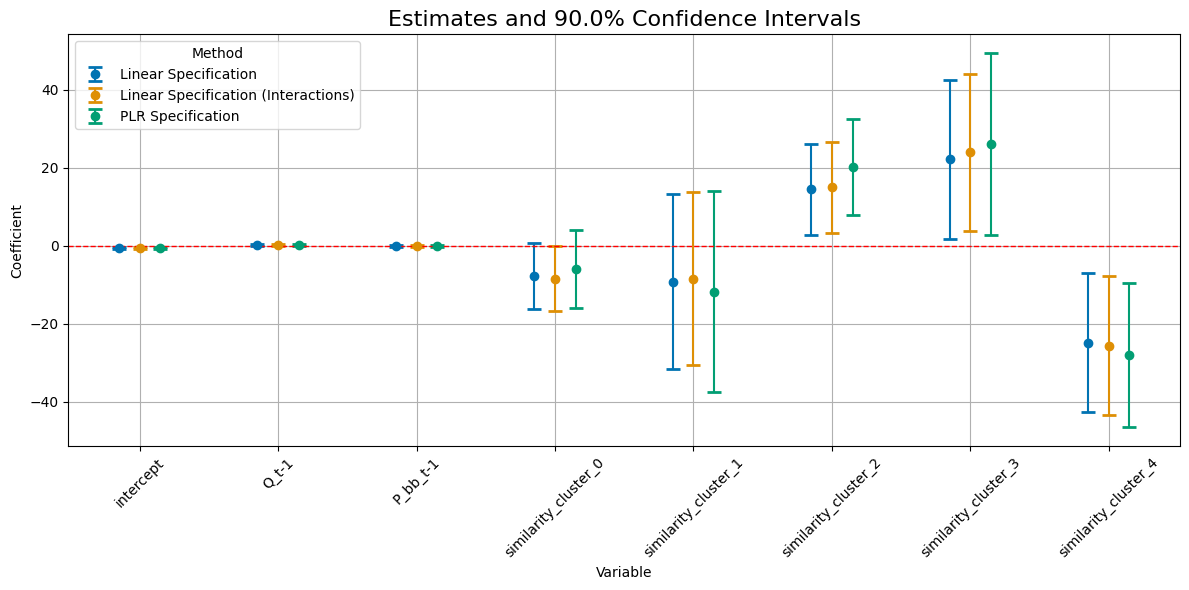

In [46]:
models = cate_summary_df["model"].unique()
variables = cate_summary_df["variable"].unique()
plt.figure(figsize=(12, 6))
bar_width = 0.15
x_positions = np.arange(len(variables))
for i, model in enumerate(models):
    df_model = cate_summary_df[cate_summary_df["model"] == model]
    if not df_model.empty:
        plt.errorbar(
            x_positions + i * bar_width,
            df_model["coef"],
            yerr=[
                df_model["coef"] - df_model["lower"],
                df_model["upper"] - df_model["coef"],
            ],
            fmt="o",
            label=model,
            capsize=5,
            capthick=2,
            ecolor=palette[i % len(palette)],
            color=palette[i % len(palette)],
            zorder=2,
        )
plt.xticks(x_positions + (len(models) - 1) * bar_width / 2, variables, rotation=45)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Estimates and {ci_level_name} Confidence Intervals", fontsize=16)
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"cluster_and_level_cate_estimates.png"))
plt.show()

### $R^2$

In [47]:
alpha_x_lin = cate_models_polynomial["Linear Specification"].predict(df_basis)
alpha_x_lin_interactions = cate_models_polynomial[
    "Linear Specification (Interactions)"
].predict(df_basis)
alpha_x_plr = cate_models_polynomial["PLR Specification"].blp_model.predict(df_basis)


print("Linear Specification")
model_lin_emb = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[embeddings])).fit()
model_lin_sim = sm.OLS(
    alpha_x_lin, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_lin_lvl = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[lag_1_vars])).fit()

print("Variance explained by embeddings: ", model_lin_emb.rsquared)
print("Variance explained by similarities: ", model_lin_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_lvl.rsquared)

print("Linear Specification with interactions")
model_lin_interactions_emb = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[embeddings])
).fit()
model_lin_interactions_sim = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_lin_interactions_lvl = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[lag_1_vars])
).fit()
print("Variance explained by embeddings: ", model_lin_interactions_emb.rsquared)
print("Variance explained by similarities: ", model_lin_interactions_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_interactions_lvl.rsquared)

print("PLR Specification")
model_plr_emb = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[embeddings])).fit()
model_plr_sim = sm.OLS(
    alpha_x_plr, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_plr_lvl = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[lag_1_vars])).fit()
print("Variance explained by embeddings: ", model_plr_emb.rsquared)
print("Variance explained by similarities: ", model_plr_sim.rsquared)
print("Variance explained by lagged variables: ", model_plr_lvl.rsquared)

Linear Specification
Variance explained by embeddings:  0.8311405707008763
Variance explained by similarities:  0.7793932880719746
Variance explained by lagged variables:  0.07064591721070335
Linear Specification with interactions
Variance explained by embeddings:  0.8523808801570699
Variance explained by similarities:  0.8049260659118341
Variance explained by lagged variables:  0.05295616033593886
PLR Specification
Variance explained by embeddings:  0.9220833303277652
Variance explained by similarities:  0.8967611190553697
Variance explained by lagged variables:  0.007836637873086971


## $\Chi^2$ Test

In [48]:
controls_similarities

['similarity_cluster_0',
 'similarity_cluster_1',
 'similarity_cluster_2',
 'similarity_cluster_3',
 'similarity_cluster_4']

In [49]:
# select index with cluster similarity
cluster_treatment_ids = [
    i
    for i, variable in enumerate(df_basis.columns)
    if variable in controls_similarities
]
cluster_treatment_ids

[3, 4, 5, 6, 7]

In [50]:
lin_p_val = chi2_test(
    cate_models_polynomial["Linear Specification"], cluster_treatment_ids
)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial["Linear Specification (Interactions)"], cluster_treatment_ids
)
tab_dml_p_val = chi2_test(
    cate_models_polynomial["PLR Specification"], cluster_treatment_ids
)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(
    f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})"
)
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 0.028731431431341492 (sample size: 13734)
Linear Specification (Interactions) p-value: 0.020861072233259836 (sample size: 13734)
PLR Specification p-value: 0.006218504494625687 (sample size: 13734)


In [51]:
het_ids = [0, 1, 2, 3, 4, 5, 6, 7]

lin_p_val = chi2_test(cate_models_polynomial["Linear Specification"], het_ids)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial["Linear Specification (Interactions)"], het_ids
)
tab_dml_p_val = chi2_test(cate_models_polynomial["PLR Specification"], het_ids)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(
    f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})"
)
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 2.2264320974629825e-06 (sample size: 13734)
Linear Specification (Interactions) p-value: 7.552985781256183e-07 (sample size: 13734)
PLR Specification p-value: 9.601945337167628e-06 (sample size: 13734)


## Sorted Effects

In [52]:
cluster_treatment_ids

[3, 4, 5, 6, 7]

In [53]:
treatment_ids = [0, 1, 2] + cluster_treatment_ids
df_basis_sorted = df_basis.iloc[:, treatment_ids]  # .join(df_dynamic[["ASIN", "date"]])

In [54]:
df_basis_sorted

,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,1.108824,-2.561720,-0.090924,0.795701,0.477067,-0.830146,-0.735317
1,1.0,-0.039231,-2.159645,0.338004,0.692736,0.195288,-0.532244,-0.702744
2,1.0,0.718854,-0.089486,-0.388050,-0.888852,-0.284905,0.689886,0.877391
3,1.0,0.649017,0.253484,0.183060,-0.423084,-0.376687,0.509787,0.321425
4,1.0,1.330221,-2.561720,-0.461370,0.624563,0.826551,-0.823152,-0.350434
...,...,...,...,...,...,...,...,...
13729,1.0,-0.388799,0.924171,-0.148795,-0.904381,-0.488935,0.818245,0.802715
13730,1.0,-1.673683,-1.605176,-0.194865,0.817711,0.679877,-0.886686,-0.629058
13731,1.0,-0.298488,0.842905,-0.055546,-0.888981,-0.566566,0.861116,0.758960
13732,1.0,0.187685,0.684729,0.289756,-0.245121,-0.328218,0.385848,0.160437


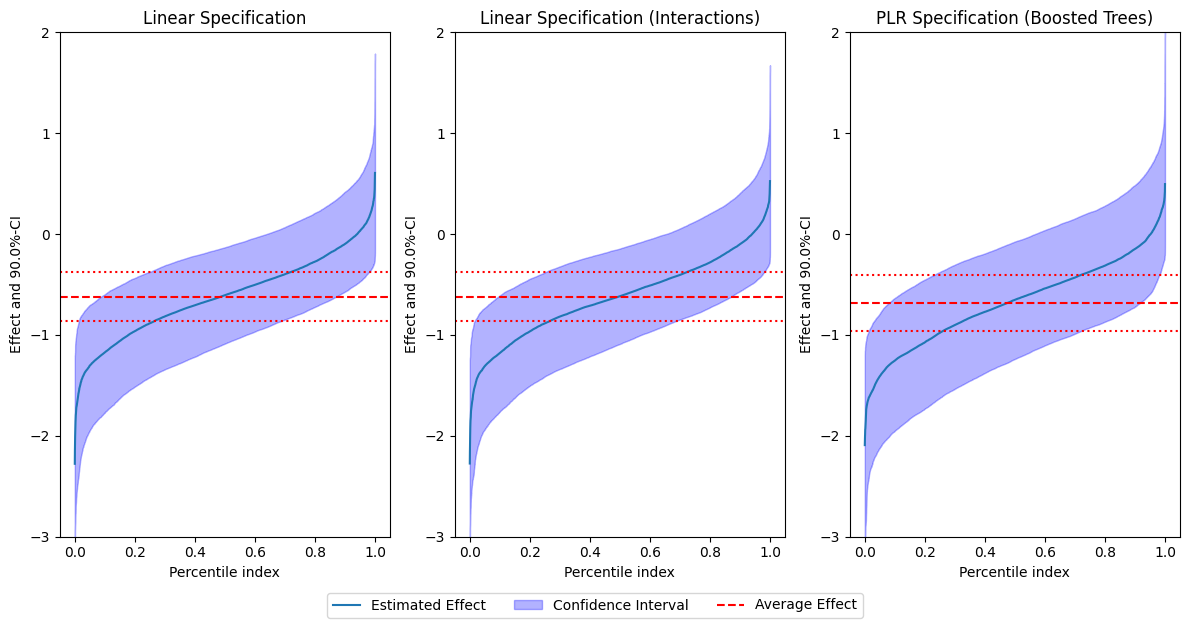

In [55]:
uniform_ci = False

plt.rcParams["figure.figsize"] = (
    15.0,
    7.5,
)  # Adjusted the figure size for side-by-side plots
# Determine the number of models to plot
num_plots = 1
# Create subplots with cate_vars as rows and models as columns
fig, axs = plt.subplots(nrows=num_plots, ncols=3, figsize=(12, 6 * num_plots))
# If there's only one model, axs won't be a list, so wrap it in a list
if num_plots == 1:
    axs = np.array([axs, axs])  # Create a 2-column array


# Linear model
df_lin_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_lin_ci_pointwise_sorted = df_lin_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_lin_ci_uniform = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_lin_ci_uniform_sorted = df_lin_ci_uniform.apply(
    lambda x: x.sort_values().values, axis=0
)
lm_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
lm_intercept_ci = (
    cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
)

# Tabular DML model
df_tab_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_tab_dml_ci_pointwise_sorted = df_tab_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_tab_dml_ci_joint = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_tab_dml_ci_joint_sorted = df_tab_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)

tab_dml_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
tab_dml_intercept_ci = (
    cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
)

# PLR Model
df_deep_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["PLR Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_deep_dml_ci_pointwise_sorted = df_deep_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_deep_dml_ci_joint = predict_cate(
    cate_models_polynomial["PLR Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_deep_dml_ci_joint_sorted = df_deep_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)
deep_dml_intercept = cate_models_polynomial["PLR Specification"].blp_model.params[
    "intercept"
]
deep_dml_intercept_ci = (
    cate_models_polynomial["PLR Specification"].blp_model.conf_int().loc["intercept"]
)

# Calculate the y-axis limits for this row
y_min = min(
    df_lin_ci_pointwise[ci_names[0]].min(),
    df_lin_ci_uniform[ci_names[0]].min(),
    df_tab_dml_ci_pointwise[ci_names[0]].min(),
    df_tab_dml_ci_joint[ci_names[0]].min(),
    df_deep_dml_ci_pointwise[ci_names[0]].min(),
    df_deep_dml_ci_joint[ci_names[0]].min(),
)
y_max = max(
    df_lin_ci_pointwise[ci_names[1]].max(),
    df_lin_ci_uniform[ci_names[1]].max(),
    df_tab_dml_ci_pointwise[ci_names[1]].max(),
    df_tab_dml_ci_joint[ci_names[1]].max(),
    df_deep_dml_ci_pointwise[ci_names[1]].max(),
    df_deep_dml_ci_joint[ci_names[1]].max(),
)

# further adjust y-axis limits
y_min = max(y_min, -3.0)
y_max = min(y_max, 2.0)
percentiles_idx = np.linspace(0, 1, df_dynamic.shape[0])
percentiles_idx_full = np.linspace(0, 1, df_dynamic.shape[0])
# Plot on the first column
i = 0
ax0 = axs[i, 0]
ax0.plot(
    percentiles_idx_full, df_lin_ci_pointwise_sorted["effect"], label="Estimated Effect"
)
ax0.fill_between(
    percentiles_idx_full,
    df_lin_ci_pointwise_sorted[ci_names[0]],
    df_lin_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax0.fill_between(
        percentiles_idx_full,
        df_lin_ci_uniform_sorted[ci_names[0]],
        df_lin_ci_uniform_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax0.axhline(y=lm_intercept, color="r", linestyle="--", label="ATE")
ax0.axhline(y=lm_intercept_ci[0], color="r", linestyle="dotted")
ax0.axhline(y=lm_intercept_ci[1], color="r", linestyle="dotted")
ax0.set_title("Linear Specification")
ax0.set_xlabel("Percentile index")
ax0.set_ylabel(f"Effect and {ci_level_name}-CI")
ax0.set_ylim(y_min, y_max)
ax1 = axs[i, 1]
ax1.plot(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax1.fill_between(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted[ci_names[0]],
    df_tab_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax1.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_joint_sorted[ci_names[0]],
        df_tab_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax1.axhline(y=tab_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax1.axhline(y=tab_dml_intercept_ci[0], color="r", linestyle="dotted")
ax1.axhline(y=tab_dml_intercept_ci[1], color="r", linestyle="dotted")
ax1.set_title("Linear Specification (Interactions)")
ax1.set_xlabel("Percentile index")
ax1.set_ylabel(f"Effect and {ci_level_name}-CI")
ax1.set_ylim(y_min, y_max)

ax2 = axs[i, 2]
ax2.plot(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax2.fill_between(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted[ci_names[0]],
    df_deep_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax2.fill_between(
        percentiles_idx_full,
        df_deep_dml_ci_joint_sorted[ci_names[0]],
        df_deep_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax2.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax2.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
ax2.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

ax2.set_title("PLR Specification (Boosted Trees)")
ax2.set_xlabel("Percentile index")
ax2.set_ylabel(f"Effect and {ci_level_name}-CI")
ax2.set_ylim(y_min, y_max)

# Create a single legend for all plots and place it at the lower center
handles, labels = axs[
    -1, 1
].get_legend_handles_labels()  # Collect handles and labels from the last subplot
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4)
# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.0, 1, 1])  # Leave space at the bottom for the legend

# Save the figure with tight bounding box to include the legend
plt.savefig(os.path.join(output_dir, "cluster_sorted_effects.png"), bbox_inches="tight")
plt.show()

In [56]:
quantiles = np.arange(start=0.01, stop=1, step=0.01)
m = len(quantiles)
pes = df_tab_dml_ci_pointwise["effect"]
spes = df_tab_dml_ci_pointwise["effect"].quantile(quantiles).values
spes

array([-1.61950377, -1.47430075, -1.39203828, -1.35321393, -1.30960368,
       -1.27808557, -1.25161673, -1.22588626, -1.20411791, -1.17963877,
       -1.15641507, -1.12891881, -1.10713094, -1.08327173, -1.05929197,
       -1.03914038, -1.01901934, -1.00062025, -0.98232765, -0.96525764,
       -0.94671773, -0.93070186, -0.91365879, -0.89813629, -0.88574033,
       -0.87235995, -0.8568955 , -0.84325472, -0.83025531, -0.81925087,
       -0.80667683, -0.79729149, -0.78486749, -0.7738956 , -0.76203605,
       -0.75165652, -0.73940492, -0.72865791, -0.71914915, -0.71066597,
       -0.70232991, -0.69220567, -0.68257435, -0.67337796, -0.66336898,
       -0.65386042, -0.6450882 , -0.63529252, -0.62583789, -0.61634407,
       -0.6062716 , -0.59591196, -0.58543348, -0.57481999, -0.56420912,
       -0.55283365, -0.54097439, -0.53015396, -0.5203597 , -0.5104397 ,
       -0.50119332, -0.49153168, -0.481317  , -0.4706808 , -0.45990321,
       -0.4476284 , -0.4362662 , -0.42703558, -0.41608748, -0.40